In [25]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'y dataset')

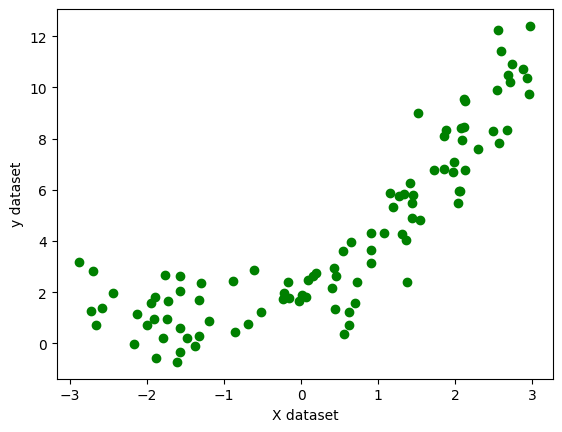

In [26]:
X = 6 * np.random.rand(100, 1) - 3  # Want to add some outliers to x by subtracting it with 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# Quadratic equation used- y = 0.5x^2 + 1.5x + 2 + outlier
plt.scatter(X, y, color='g')
plt.xlabel("X dataset")
plt.ylabel("y dataset")

## Train Test Split

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [29]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
## Let's implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [31]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.6887179390991822


Text(0, 0.5, 'Y')

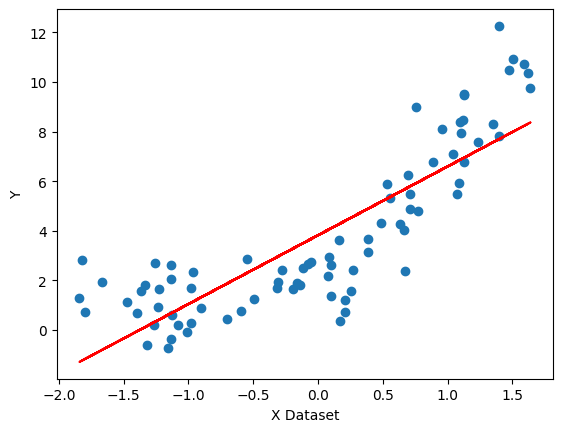

In [33]:
## Let's visualize this model
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [34]:
## There is a good amount of error

## Let's see how do we solve this problem with the help of polynomial regression

## We will first try y = b0 + b1x1 + b2((x2)^2)
## If not suitable, we try to increase the polynomial degree more and see whether my line will fit or not

## Later on, we will try to create a common function which will do all the specific task

In [35]:
## Let's apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

## polynomial features is used for the transformation like to increase the degree

In [36]:
poly = PolynomialFeatures(degree=2, include_bias=True)  
## y = y = b0 + b1x1 + b2((x2)^2), if include_bias = True, it becomes; 
## y = y = b0*1 + b1x1 + b2((x2)^2) and 1, x1, (x1)^2 are taken for our model training

X_train_poly = poly.fit_transform(X_train)
X_test_poly =poly.transform(X_test)

In [37]:
X_train_poly
#   [[     1,                x1,              (x1)^2   ]]       Since include_bias = True

array([[ 1.00000000e+00, -3.16323831e-01,  1.00060766e-01],
       [ 1.00000000e+00,  7.60407507e-02,  5.78219576e-03],
       [ 1.00000000e+00, -1.25483213e+00,  1.57460368e+00],
       [ 1.00000000e+00,  7.07935124e-01,  5.01172140e-01],
       [ 1.00000000e+00, -9.79474364e-01,  9.59370030e-01],
       [ 1.00000000e+00, -1.79645784e+00,  3.22726076e+00],
       [ 1.00000000e+00, -1.15479487e+00,  1.33355118e+00],
       [ 1.00000000e+00, -1.64525931e-01,  2.70687820e-02],
       [ 1.00000000e+00,  1.62115448e+00,  2.62814185e+00],
       [ 1.00000000e+00, -1.16240797e-01,  1.35119230e-02],
       [ 1.00000000e+00,  1.12836864e+00,  1.27321578e+00],
       [ 1.00000000e+00, -1.66504732e+00,  2.77238258e+00],
       [ 1.00000000e+00,  6.64872753e-01,  4.42055777e-01],
       [ 1.00000000e+00,  6.95120441e-01,  4.83192427e-01],
       [ 1.00000000e+00,  4.84948661e-01,  2.35175204e-01],
       [ 1.00000000e+00, -1.84080128e+00,  3.38854936e+00],
       [ 1.00000000e+00, -4.90270582e-01

In [38]:
X_test_poly

array([[ 1.        ,  1.46528947,  2.14707324],
       [ 1.        ,  0.97926173,  0.95895355],
       [ 1.        , -1.34192073,  1.80075124],
       [ 1.        , -1.74896231,  3.05886915],
       [ 1.        ,  1.4899725 ,  2.22001806],
       [ 1.        , -0.27102548,  0.07345481],
       [ 1.        , -0.71035741,  0.50460765],
       [ 1.        ,  1.64787263,  2.71548421],
       [ 1.        ,  0.6083189 ,  0.37005189],
       [ 1.        ,  0.71845652,  0.51617977],
       [ 1.        , -1.93002246,  3.72498668],
       [ 1.        ,  0.22171002,  0.04915533],
       [ 1.        ,  0.38510958,  0.14830939],
       [ 1.        , -1.49373052,  2.23123086],
       [ 1.        ,  1.41293732,  1.99639188],
       [ 1.        ,  1.03423925,  1.06965083],
       [ 1.        ,  0.96332535,  0.92799573],
       [ 1.        ,  1.38454556,  1.9169664 ],
       [ 1.        ,  1.07950195,  1.16532445],
       [ 1.        ,  0.6419203 ,  0.41206168]])

Now once we have this dataset, try to apply the same linear regression whatever we did

In [39]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9147719068400482


In [40]:
print(regression.coef_)

[[0.         2.99564167 1.53912942]]


In [41]:
print(regression.intercept_)

[2.28354612]


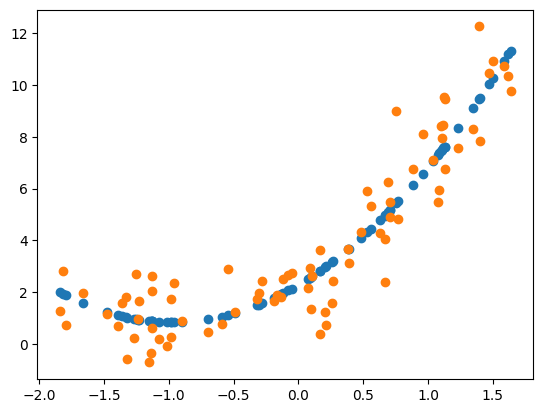

In [42]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

What if we give degree = 3

In [46]:
poly = PolynomialFeatures(degree=3, include_bias=True)  
X_train_poly = poly.fit_transform(X_train)
X_test_poly =poly.transform(X_test)

In [48]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9146096274298204


## Prediction of new data set

In [49]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

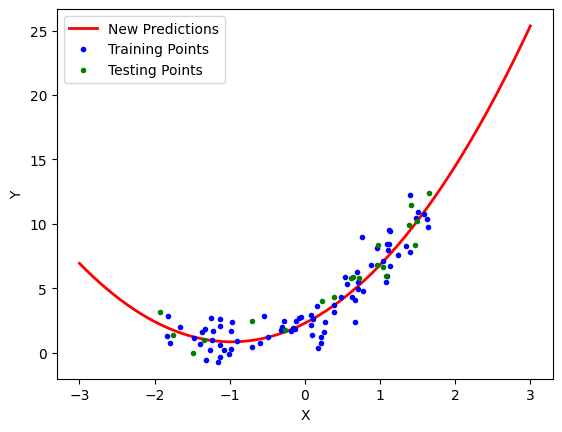

In [57]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.", label="Training Points")
plt.plot(X_test, y_test, "g.", label="Testing Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Pipeline Concepts

In this concept, we have to create a generic function in which whatever degree you assign, you will be able to see what kind of curve
it will be fitting to, for a new data set

In [58]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    poly_features = PolynomialFeatures(degree = degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_red", lin_reg)
    ])
    poly_regression.fit(X_train, y_train) # Polynomial features and fit og linear regression
    y_pred_new = poly_regression.predict(X_new)
    # Plotting prediction line
    plt.plot(X_new, y_pred_new, 'r', label="Degree" + str(degree), linewidth=3)
    plt.plot(X_train, y_train, 'b.', linewidth=3)
    plt.plot(X_test, y_test, 'g.', linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

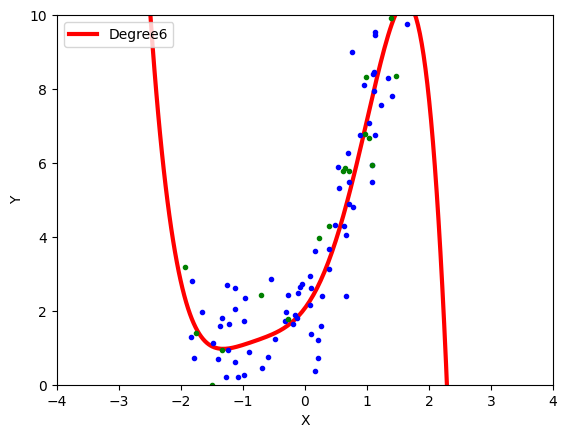

In [76]:
poly_regression(6)